# **ES 335 - Machine Learning Assignment 3**

**Name: Niraj Kumar**

**Roll: 24110222**

# Importing Modules and Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, KFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Question 1

**Classification:** Consider the Car Evaluation dataset (available at `https://archive.ics.uci.edu/dataset/19/car+evaluation`) and implement the following:

* Grow a decision tree using either the entropy measure (ID3 algorithm) or the Gini index (CART algorithm). Decision trees tend to be overly complex and may not generalize well to unseen data, leading to overfitting. To address this, use stopping criteria such as limiting the maximum depth of the tree $T$.

  Use cross-validation to determine the optimal depth $T$ that maximizes performance. Plot the average accuracy as a function of $T$. Visualize the decision tree constructed on the training data.

* **Ensemble methods to overcome overfitting:**

  – **Bagging:** For the optimal value of $T$ identified above,     perform bagging using $B$ bootstrapped datasets. Consider $B$ in the range of 50 to 500 with increments of 50. Use cross-validation to select the optimal value of $B$. Plot the average accuracy as a function of $B$.

  – **Random Forest:** Construct a random forest consisting of $B$ trees using the optimal value of $B$ obtained above. For each tree, at each split, randomly select $m$ out of $d$ features (where
  $m$ can range from $\sqrt d$  to  $d$). Compute the average classification accuracy for $m$ = 4.

**Decision Tree and Finding Optimal Depth ($T$)**

In [ ]:
# Loading the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data"
columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df = pd.read_csv(url, names=columns)


X = df.drop('class', axis=1)
y = df['class']

encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(X)

# Optimal max_depth (T) using Cross-Validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)
T_values = range(1, 21)
accuracies_T = []

for T in T_values:
    # Using Entropy (ID3 algorithm)
    dt = DecisionTreeClassifier(criterion='entropy', max_depth=T, random_state=42)
    scores = cross_val_score(dt, X_encoded, y, cv=cv, scoring='accuracy')
    accuracies_T.append(scores.mean())

optimal_T = T_values[np.argmax(accuracies_T)]
print(f"Optimal tree depth (T): {optimal_T}")

Optimal tree depth (T): 12


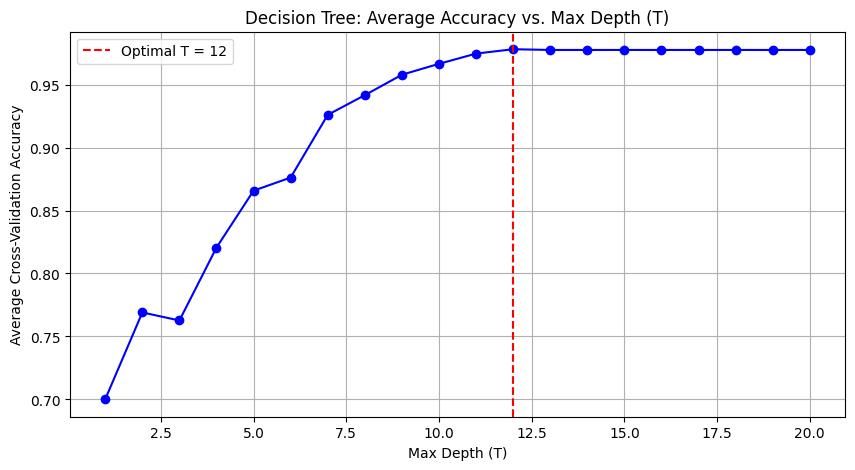

In [ ]:
# Plotting Average Accuracy vs T
plt.figure(figsize=(10, 5))
plt.plot(T_values, accuracies_T, marker='o', linestyle='-', color='b')
plt.axvline(x=optimal_T, color='red', linestyle='--', label=f'Optimal T = {optimal_T}')
plt.title('Decision Tree: Average Accuracy vs. Max Depth (T)')
plt.xlabel('Max Depth (T)')
plt.ylabel('Average Cross-Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

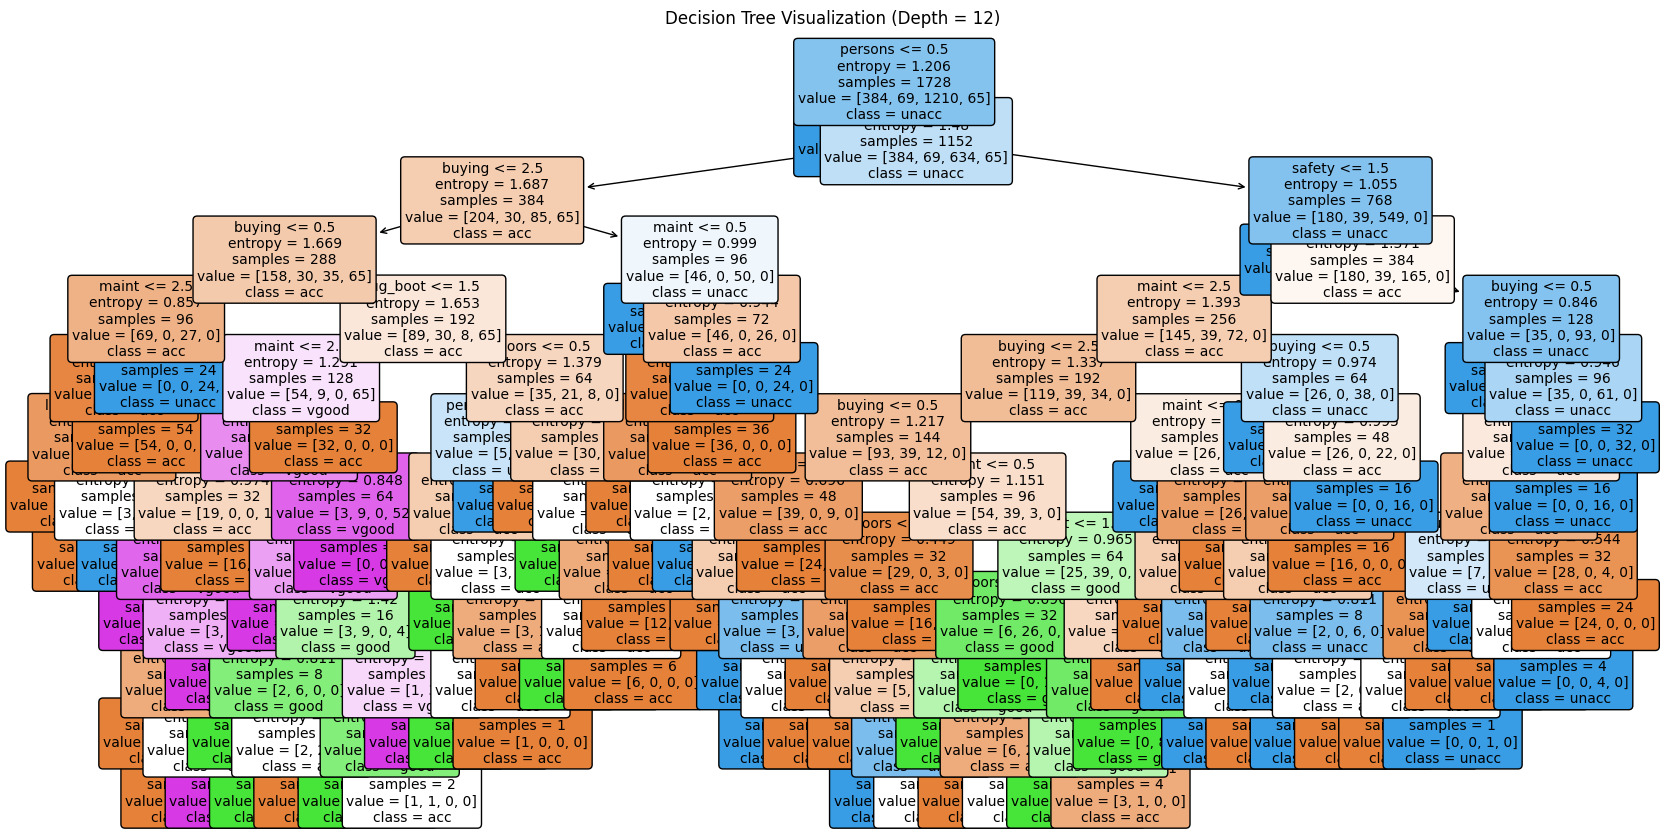

In [ ]:
# Visualizing the decision tree constructed on the full training data using optimal T
best_dt = DecisionTreeClassifier(criterion='entropy', max_depth=optimal_T, random_state=42)
best_dt.fit(X_encoded, y)

plt.figure(figsize=(20, 10))
plot_tree(best_dt, feature_names=X.columns, class_names=np.unique(y), filled=True, rounded=True, fontsize=10)
plt.title(f"Decision Tree Visualization (Depth = {optimal_T})\n")
plt.show()

**Bagging and Finding Optimal Number of Trees ($B$)**

In [ ]:
# Range of B
B_values = range(50, 501, 50)
accuracies_B = []

base_estimator = DecisionTreeClassifier(criterion='entropy', max_depth=optimal_T, random_state=42)

# Using cross validation to select optimal B
for B in B_values:
    bagging_model = BaggingClassifier(estimator=base_estimator, n_estimators=B, random_state=42)
    scores = cross_val_score(bagging_model, X_encoded, y, cv=cv, scoring='accuracy')
    accuracies_B.append(scores.mean())

optimal_B = B_values[np.argmax(accuracies_B)]
print(f"Optimal number of trees for Bagging (B): {optimal_B}")

Optimal number of trees for Bagging (B): 300


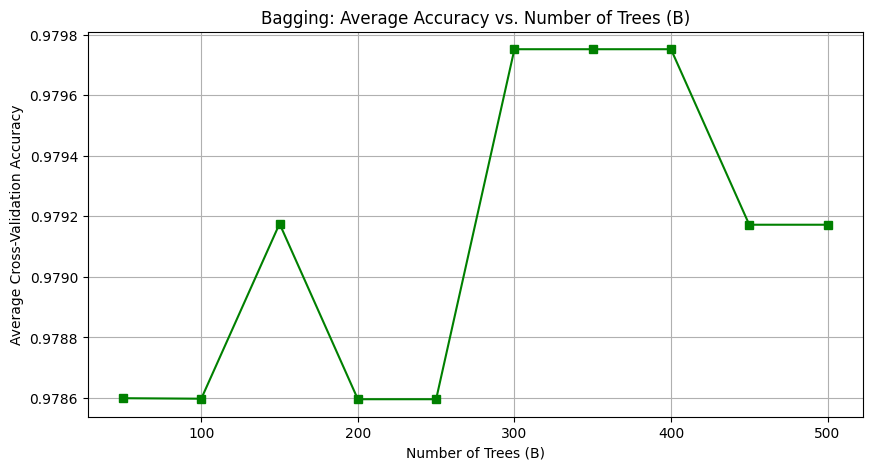

In [ ]:
# Plotting Average Accuracy vs B
plt.figure(figsize=(10, 5))
plt.plot(B_values, accuracies_B, marker='s', linestyle='-', color='g')
plt.title('Bagging: Average Accuracy vs. Number of Trees (B)')
plt.xlabel('Number of Trees (B)')
plt.ylabel('Average Cross-Validation Accuracy')
plt.grid(True)
plt.show()

**Random Forest with $m=4$**

In [ ]:
m = 4

# Initializing Random Forest with optimal B and max_features = m
rf_model = RandomForestClassifier(
    n_estimators=optimal_B,
    criterion='entropy',
    max_depth=optimal_T,
    max_features=m,
    random_state=42
)

rf_scores = cross_val_score(rf_model, X_encoded, y, cv=cv, scoring='accuracy')
rf_average_accuracy = rf_scores.mean()

print(f"Random Forest Average Accuracy (B={optimal_B}, m={m}, max_depth={optimal_T}): {rf_average_accuracy:.4f}")

Random Forest Average Accuracy (B=300, m=4, max_depth=12): 0.9774


# Question 2

**Regression:** Using the Boston Housing dataset (available at `http://lib.stat.cmu.edu/datasets/boston`), perform decision tree regression to predict the value of MEDV, which represents the median price of owner-occupied homes.

* Grow a regression tree using recursive binary splitting. Decision trees tend to be overly complex and may not generalize well to unseen data, leading to overfitting. To address this, use stopping criteria such as limiting the maximum depth of the tree or the minimum number of samples in a terminal node $S$. Use $S$ = 4.

  Visualize the regression tree constructed on the training data.

* Ensemble methods to overcome overfitting:

  – **Bagging:** For the value of $S$ identified above, perform bagging using $B$ bootstrapped datasets. Consider B in the range of 50 to 500 with increments of 50. Use cross-validation to determine
  the optimal value of $B$. Plot the average mean squared error (MSE) as a function of $B$.

  – **Random Forest:** Construct a random forest consisting of $B$ trees using the optimal value of $B$ obtained above. For each tree, at each split, randomly select $m$ out of $d$ features (where $m$ ranges from $\sqrt d$ to $d$). Compute the average prediction accuracy for $m$ = 7.

In [ ]:
# Loading the dataset
url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(url, sep=r"\s+", skiprows=22, header=None)

# The raw data have two rows per record so we have to stack them correctly
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

feature_names = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
                 "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"]

X = pd.DataFrame(data, columns=feature_names)
y = pd.Series(target, name="MEDV")

**Visualizing the Decision Tree**

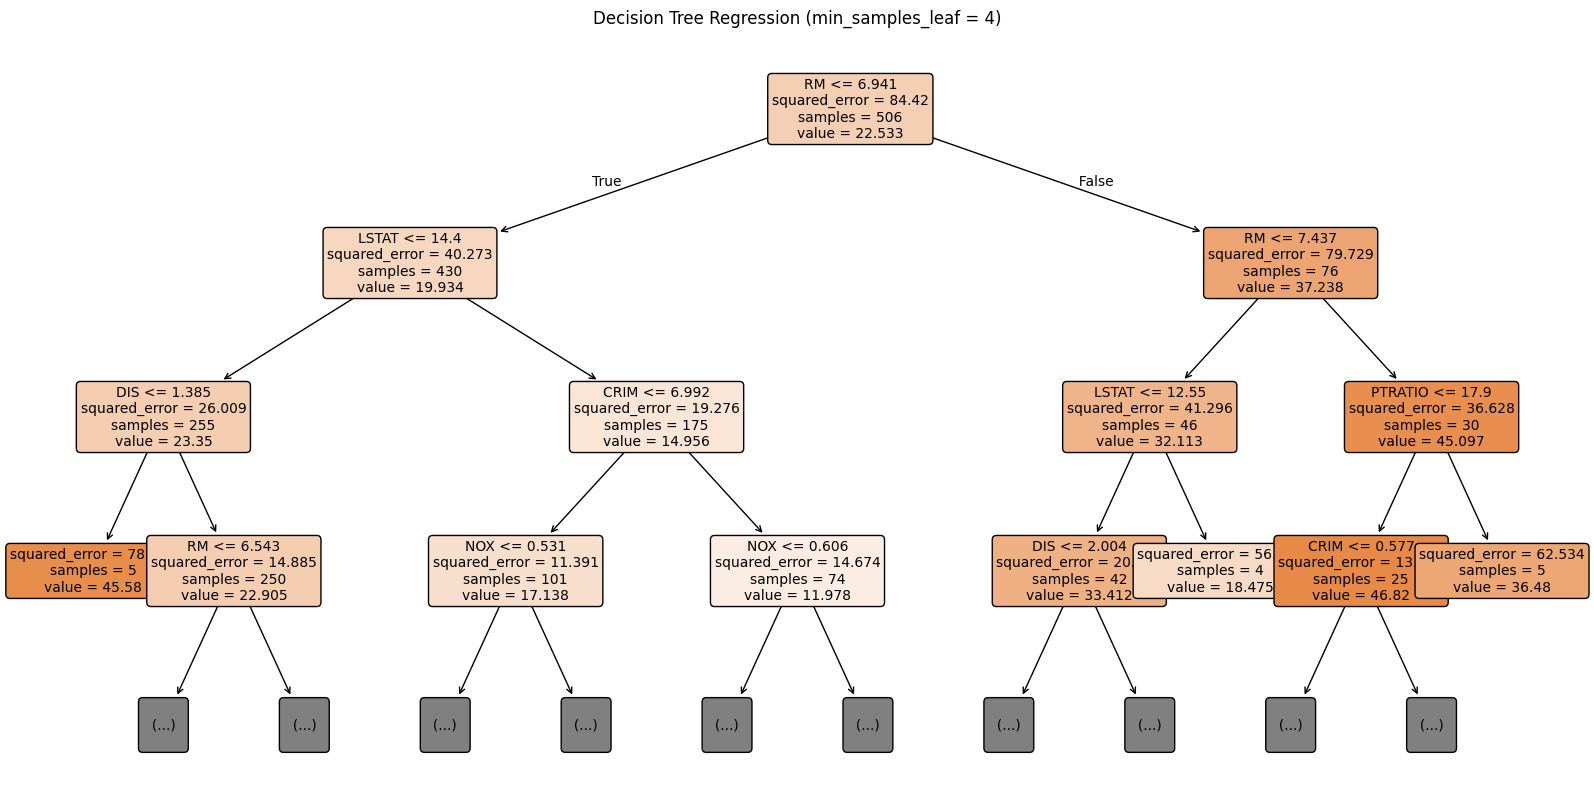

In [ ]:
# Stopping criteria
S = 4

tree_reg = DecisionTreeRegressor(min_samples_leaf=S, random_state=42)
tree_reg.fit(X, y)

# Visualizing the tree
plt.figure(figsize=(20, 10))

# Note: Limited max_depth here for better visualization o/w the plot becomes too cluttered to read.
plot_tree(tree_reg, feature_names=X.columns, filled=True, rounded=True,
          max_depth=3, fontsize=10)
plt.title(f"Decision Tree Regression (min_samples_leaf = {S})")
plt.show()

**Bagging and Finding Optimal $B$**

In [ ]:
# Range of B
B_values = range(50, 501, 50)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

mse_scores_bagging = []

base_estimator = DecisionTreeRegressor(min_samples_leaf=S, random_state=42)

# Evaluating MSE for each value of B
for B in B_values:
    bag_model = BaggingRegressor(estimator=base_estimator,n_estimators=B,random_state=42)

    # scikit-learn uses negative MSE for scoring so I negated it to get positive MSE
    scores = -cross_val_score(bag_model, X, y, cv=cv, scoring='neg_mean_squared_error')
    mse_scores_bagging.append(scores.mean())

optimal_B = B_values[np.argmin(mse_scores_bagging)]
print(f"Optimal number of trees for Bagging (B): {optimal_B}")

Optimal number of trees for Bagging (B): 350


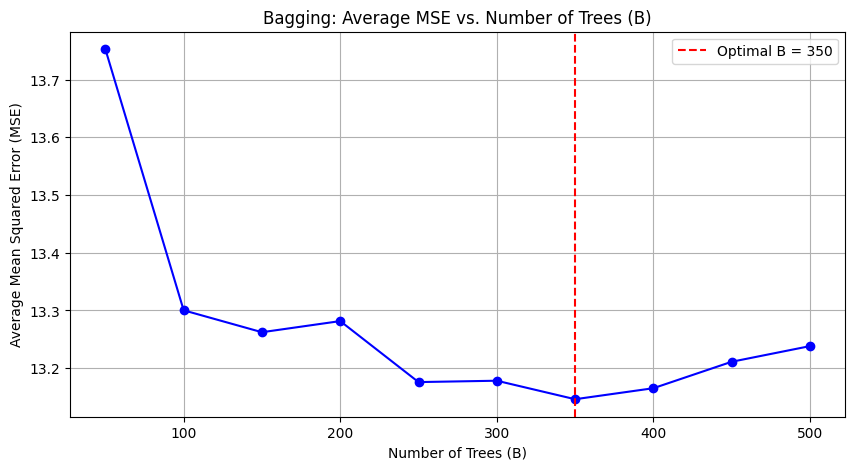

In [ ]:
# Plotting Average MSE vs B
plt.figure(figsize=(10, 5))
plt.plot(B_values, mse_scores_bagging, marker='o', linestyle='-', color='b')
plt.axvline(x=optimal_B, color='red', linestyle='--', label=f'Optimal B = {optimal_B}')
plt.title('Bagging: Average MSE vs. Number of Trees (B)')
plt.xlabel('Number of Trees (B)')
plt.ylabel('Average Mean Squared Error (MSE)')
plt.grid(True)
plt.legend()
plt.show()

**Random Forest Regression**

In [ ]:
m = 7

# Initializing Random Forest with optimal B and max_features = m
rf_model_reg = RandomForestRegressor(
    n_estimators=optimal_B,
    min_samples_leaf=S,
    max_features=m,
    random_state=42
)

# Computing average MSE scores
rf_mse_scores = -cross_val_score(rf_model_reg, X, y, cv=cv, scoring='neg_mean_squared_error')
rf_average_mse = rf_mse_scores.mean()

# Computing R-squared value
rf_r2_scores = cross_val_score(rf_model_reg, X, y, cv=cv, scoring='r2')
rf_average_r2 = rf_r2_scores.mean()

print(f"Random Forest Results")
print(f"Parameters: B={optimal_B}, S={S}, m={m}")
print(f"Average Mean Squared Error (MSE): {rf_average_mse:.2f}")
print(f"Average R-squared (Accuracy): {rf_average_r2:.4f}")

Random Forest Results
Parameters: B=350, S=4, m=7
Average Mean Squared Error (MSE): 12.52
Average R-squared (Accuracy): 0.8465


# Acknowlegements

The assignment, with the help of language models/AI tools, is refined for better structuring of the code and diagrams. I have also used ISLP lab code/documentation and Google colab code shared by the course TA for reference.